In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
df=pd.read_csv("customer_churn.csv")
df.head(5)

,age,tenure_months,monthly_charges,support_calls,contract,internet_service,payment_method,churn
0,58,15,402,4,Monthly,DSL,Credit Card,No
1,61,70,656,6,Monthly,DSL,Credit Card,Yes
2,50,4,1114,8,One Year,DSL,Bank Transfer,No
3,69,1,953,6,One Year,Fiber,Credit Card,Yes
4,66,44,718,1,One Year,DSL,Bank Transfer,No


In [ ]:
df.shape

(500, 8)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   age               500 non-null    int64 
 1   tenure_months     500 non-null    int64 
 2   monthly_charges   500 non-null    int64 
 3   support_calls     500 non-null    int64 
 4   contract          500 non-null    object
 5   internet_service  500 non-null    object
 6   payment_method    500 non-null    object
 7   churn             500 non-null    object
dtypes: int64(4), object(4)
memory usage: 31.4+ KB


In [ ]:
df.isnull().sum()

age                 0
tenure_months       0
monthly_charges     0
support_calls       0
contract            0
internet_service    0
payment_method      0
churn               0
dtype: int64

In [ ]:
df.duplicated().sum()

np.int64(0)

In [ ]:
df["churn"].unique().sum()

'NoYes'

In [ ]:
df["churn"]=df["churn"].replace({"Yes":1,"No":0})

C:\Users\gobinath\AppData\Local\Temp\ipykernel_3504\3202989798.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df["churn"]=df["churn"].replace({"Yes":1,"No":0})


churn represent 
yes is stayed people
no coustemer lefted people

In [ ]:
df.head(5)

,age,tenure_months,monthly_charges,support_calls,contract,internet_service,payment_method,churn
0,58,15,402,4,Monthly,DSL,Credit Card,0
1,61,70,656,6,Monthly,DSL,Credit Card,1
2,50,4,1114,8,One Year,DSL,Bank Transfer,0
3,69,1,953,6,One Year,Fiber,Credit Card,1
4,66,44,718,1,One Year,DSL,Bank Transfer,0


In [ ]:
df["churn"].value_counts()

churn
0    317
1    183
Name: count, dtype: int64

In [ ]:
df.describe()

,age,tenure_months,monthly_charges,support_calls,churn
count,500.00000,500.000000,500.000000,500.000000,500.000000
mean,44.56600,37.220000,1440.782000,3.878000,0.366000
std,14.59945,20.543409,650.887862,2.636098,0.482192
min,18.00000,1.000000,302.000000,0.000000,0.000000
25%,32.00000,19.000000,843.250000,1.000000,0.000000
50%,44.00000,38.000000,1478.500000,4.000000,0.000000
75%,57.00000,54.250000,2007.750000,6.000000,1.000000
max,70.00000,72.000000,2499.000000,8.000000,1.000000


In [ ]:
df.groupby("churn")[["age","tenure_months","monthly_charges","support_calls"]].mean()

,age,tenure_months,monthly_charges,support_calls
churn,,,,
0,43.905363,37.517350,1410.826498,3.261830
1,45.710383,36.704918,1492.672131,4.945355


In [ ]:
df["contract"].value_counts()

contract
One Year    175
Monthly     164
Two Year    161
Name: count, dtype: int64

In [ ]:
df["internet_service"].value_counts()

internet_service
Fiber    181
No       166
DSL      153
Name: count, dtype: int64

In [ ]:
df["payment_method"].value_counts()

payment_method
Credit Card         193
Electronic Check    156
Bank Transfer       151
Name: count, dtype: int64

In [ ]:
df.groupby(["churn", "contract"]).size()

churn  contract
0      Monthly      78
       One Year    132
       Two Year    107
1      Monthly      86
       One Year     43
       Two Year     54
dtype: int64

In [ ]:
df.groupby(["churn", "internet_service"]).size()

churn  internet_service
0      DSL                  99
       Fiber               101
       No                  117
1      DSL                  54
       Fiber                80
       No                   49
dtype: int64

In [ ]:
df.groupby(["churn", "payment_method"]).size()

churn  payment_method  
0      Bank Transfer        86
       Credit Card         121
       Electronic Check    110
1      Bank Transfer        65
       Credit Card          72
       Electronic Check     46
dtype: int64

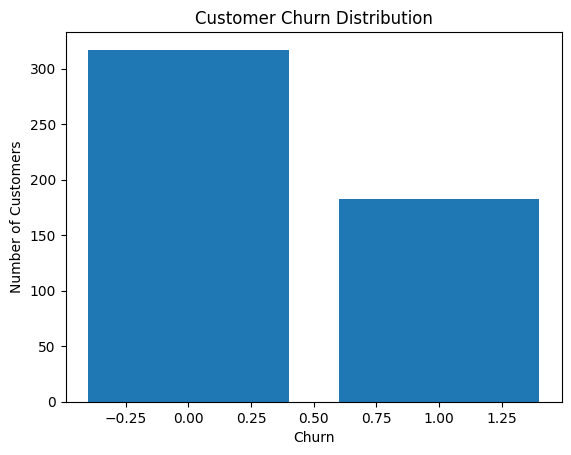

In [ ]:
churn_count = df["churn"].value_counts()

x = churn_count.index
y = churn_count.values

plt.bar(x, y)
plt.xlabel("Churn")
plt.ylabel("Number of Customers")
plt.title("Customer Churn Distribution")
plt.show()

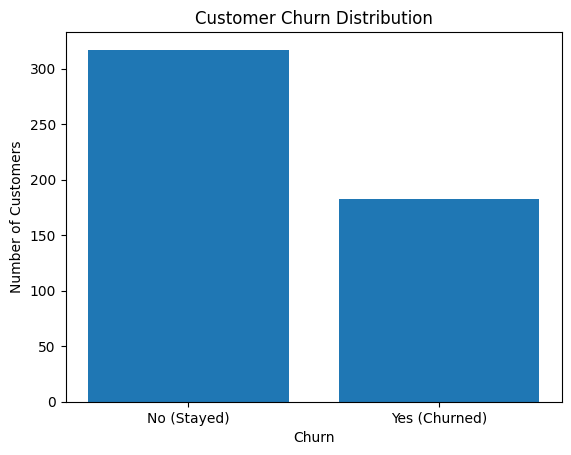

In [ ]:

plt.bar(x, y)

plt.xlabel("Churn")
plt.ylabel("Number of Customers")
plt.title("Customer Churn Distribution")

plt.xticks([0, 1], ["No (Stayed)", "Yes (Churned)"])

plt.show()

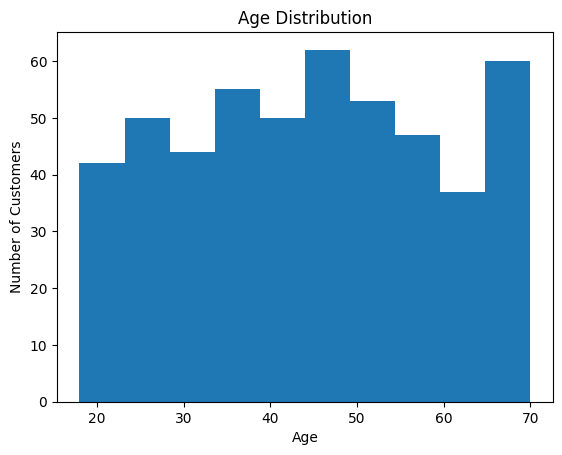

In [ ]:
plt.hist(df["age"], bins=10)

plt.xlabel("Age")
plt.ylabel("Number of Customers")
plt.title("Age Distribution")

plt.show()

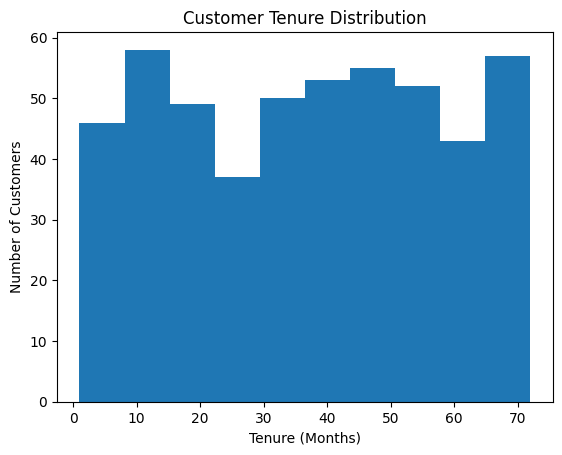

In [ ]:
plt.hist(df["tenure_months"], bins=10)

plt.xlabel("Tenure (Months)")
plt.ylabel("Number of Customers")
plt.title("Customer Tenure Distribution")

plt.show()

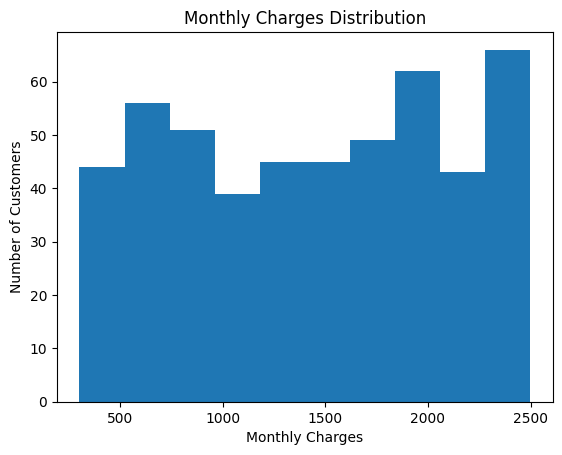

In [ ]:
plt.hist(df["monthly_charges"], bins=10)

plt.xlabel("Monthly Charges")
plt.ylabel("Number of Customers")
plt.title("Monthly Charges Distribution")

plt.show()

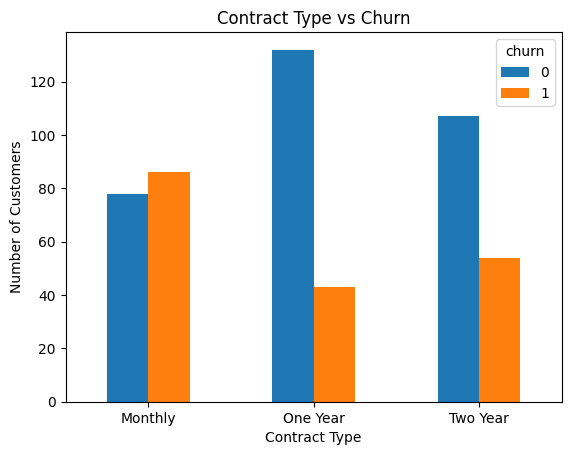

In [ ]:
contract_churn = df.groupby(["contract", "churn"]).size().unstack()

contract_churn.plot(kind="bar")

plt.xlabel("Contract Type")
plt.ylabel("Number of Customers")
plt.title("Contract Type vs Churn")

plt.xticks(rotation=0)

plt.show()

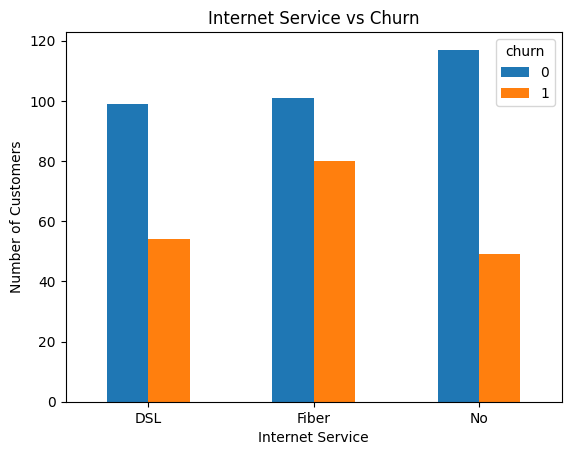

In [ ]:
internet_churn = df.groupby(["internet_service", "churn"]).size().unstack()

internet_churn.plot(kind="bar")

plt.xlabel("Internet Service")
plt.ylabel("Number of Customers")
plt.title("Internet Service vs Churn")

plt.xticks(rotation=0)

plt.show()

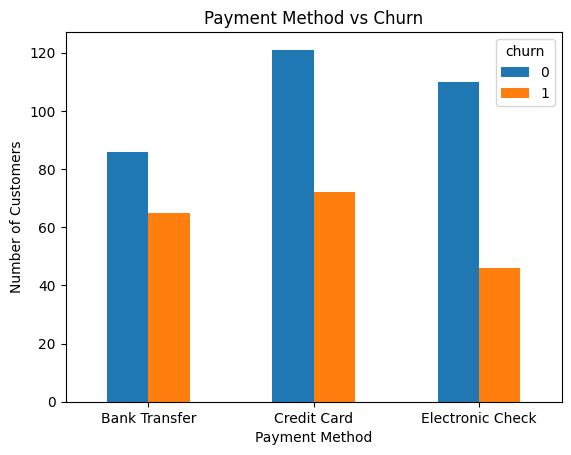

In [ ]:
payment_churn = df.groupby(["payment_method", "churn"]).size().unstack()

payment_churn.plot(kind="bar")

plt.xlabel("Payment Method")
plt.ylabel("Number of Customers")
plt.title("Payment Method vs Churn")

plt.xticks(rotation=0)

plt.show()

In [ ]:
categorical_cols = ["contract", "internet_service", "payment_method"]

df_encoded = pd.get_dummies(
    df,
    columns=categorical_cols,
    drop_first=True
)
df_encoded.head()

,age,tenure_months,monthly_charges,support_calls,churn,contract_One Year,contract_Two Year,internet_service_Fiber,internet_service_No,payment_method_Credit Card,payment_method_Electronic Check
0,58,15,402,4,0,False,False,False,False,True,False
1,61,70,656,6,1,False,False,False,False,True,False
2,50,4,1114,8,0,True,False,False,False,False,False
3,69,1,953,6,1,True,False,True,False,True,False
4,66,44,718,1,0,True,False,False,False,False,False


In [ ]:
X = df_encoded.drop("churn", axis=1)
y = df_encoded["churn"]

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [ ]:
print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

(400, 10)
(100, 10)
(400,)
(100,)


In [ ]:
model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

C:\Users\gobinath\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


In [ ]:
y_pred = model.predict(X_test)

In [ ]:
print(y_pred)

[0 0 1 0 0 1 0 0 0 0 0 0 1 0 0 1 1 0 0 0 0 1 0 0 0 0 1 0 1 0 0 0 0 1 0 0 0
 0 1 0 1 1 0 0 0 0 0 0 1 0 0 1 0 0 1 0 0 0 0 1 1 1 0 0 0 1 0 1 1 0 0 0 1 1
 1 0 0 1 0 1 1 1 0 0 0 0 0 0 0 0 0 1 0 1 0 0 1 0 1 0]


In [ ]:
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)

Accuracy: 0.65


In [ ]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)
print(cm)

[[48 15]
 [20 17]]


In [ ]:
print(y_test.unique())
print(y_pred[:10])

[0 1]
[0 0 1 0 0 1 0 0 0 0]


In [ ]:
from sklearn.metrics import recall_score

recall = recall_score(y_test, y_pred)
print("Recall:", recall)

Recall: 0.4594594594594595


In [ ]:
from sklearn.metrics import f1_score

f1 = f1_score(y_test, y_pred, pos_label=1)

print("F1-score:", f1)

F1-score: 0.4927536231884058
